In [1]:
import torch
import numpy as np
import pandas as pd
import albumentations as A

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from albumentations.pytorch.transforms import ToTensorV2
import timm

In [2]:
import math
from functools import partial
from collections import Counter, defaultdict

import io
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.ops import nms, box_iou
from torchvision.models.detection.anchor_utils import AnchorGenerator


In [3]:
! kaggle datasets download -d pkdarabi/bone-fracture-detection-computer-vision-project --unzip

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project
License(s): Attribution 4.0 International (CC BY 4.0)
100% 84.1M/84.1M [00:04<00:00, 18.0MB/s]



В данном датасете представлен немного необычный формат для YOLO, здесь идёт class_id, x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4 - это oriented bounding box(obb), то есть на одном изображении может быть несколько bounding box, но для YOLO из Ultralytics нужен формат:
class_id x_1, y_1, w_1, h_1
class_id x_2, y_2, w_2, h_2. Поэтому немного обработаем наши данные(первоначально я обучил нейросеть yolov8n, и она показала довольно слабые результаты, видимо как раз потому что я не учитывал эти особенности)

In [4]:
import matplotlib.pyplot as plt
import torch, torchvision
from torchvision import transforms
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
print(device)

cpu


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00


**Посмотрим на распределение целевой переменной**

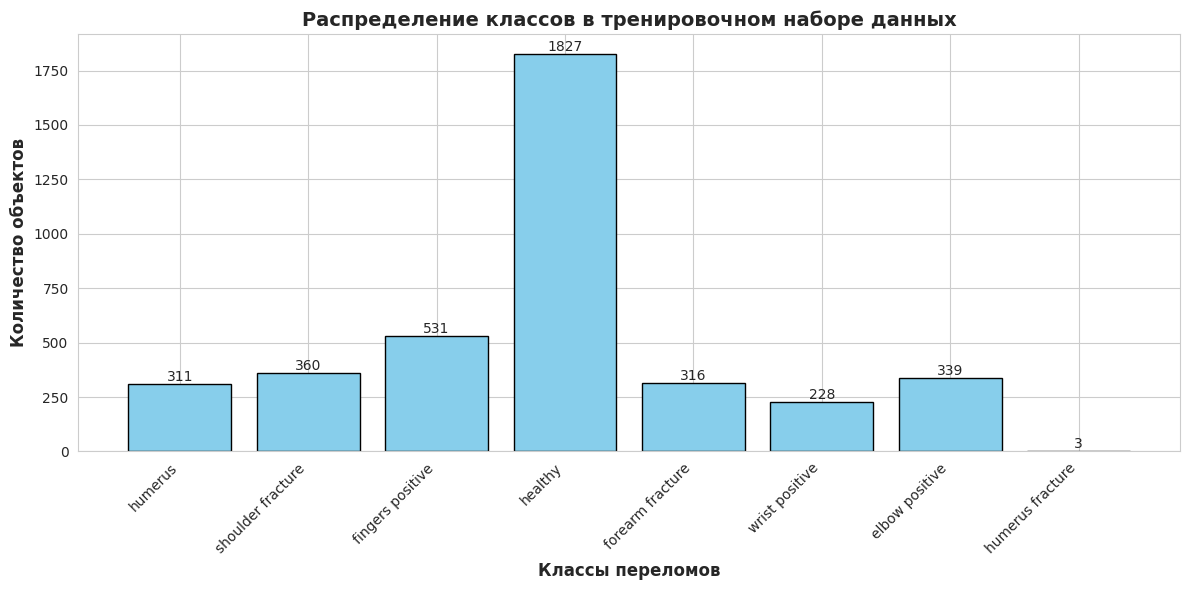

In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns


dir_train = '/content/BoneFractureYolo8/train/labels'
names = ['elbow positive', 'fingers positive', 'forearm fracture',
        'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']
class_freq = dict()
for file in os.listdir(dir_train):
  with open(f"{dir_train}/{file}", 'r') as cur_file:
      data = cur_file.readlines()
      if not data:# проверяем изображения на которых нет переломов
         class_freq['healthy'] = class_freq.get('healthy', 0) + 1
      for i in range(len(data)):
        class_freq[names[int(data[i][0])]] = class_freq.get(names[int(data[i][0])], 0) + 1
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Создание столбчатой диаграммы
bars = plt.bar(class_freq.keys(), class_freq.values(), color='skyblue', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.xlabel('Классы переломов', fontsize=12, fontweight='bold')
plt.ylabel('Количество объектов', fontsize=12, fontweight='bold')
plt.title('Распределение классов в тренировочном наборе данных', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Что характерно для медицинских данных снимков без переломов значительно больше чем с переломами, однако распределение самих переломов почти равномерное, за исключением класса humerus fracture(перелом плечевой кости), которого представлено крайне мало.

Посмотрим на размеры изображений, чтобы понять, стоит ли нам использовать методы для рассмотрения мелких элементов, например SAHI(я читал о нём в библиотеке YOLO и смотрел видео на ютуб, утверждается, что он поможет находить маленькие объекты, в нашем случае маленькие трещины)

In [ ]:
import os
import pandas as pd

images = '/content/BoneFractureYolo8/train/images'
freq_size = dict() # как часто какой размер встречается
for image in os.listdir(images):
  img = cv2.imread(f"{images}/{image}")
  width, height, color = img.shape
  freq_size[f"{width} * {height}"] = freq_size.get(f"{width} * {height}", 0) + 1

pd.DataFrame.from_dict(freq_size, orient='index')


,0
512 * 372,9
512 * 420,518
406 * 512,255
512 * 223,9
512 * 207,6
...,...
512 * 327,3
272 * 512,3
512 * 511,3
512 * 255,3


Наши изображения и так довольно маленькие, как видно из их распределения, поэтому SAHI нам здесь скорее всего не поможет

Ниже мы немного меняем представленный в датасете формат с Obb на YOLO

In [ ]:
dirs = ['/content/BoneFractureYolo8/test/labels', '/content/BoneFractureYolo8/train/labels',
        '/content/BoneFractureYolo8/valid/labels']

for dir in dirs:
  for file in os.listdir(dir):
    with open(f"{dir}/{file}", 'r') as cur_file:
      data = cur_file.readlines()
      to_write = []
      for elems in data:
        cur_elem = elems.split()
        if not cur_elem: continue # значит boundingbox'а на нашей картинке нет, а значит нет и перелома и файл просто пустой
        class_id = cur_elem[0]
        x_min = 1e9
        x_max = -1e9
        y_min = 1e9
        y_max = -1e9
        for i in range(1, min(8, len(cur_elem)), 2):
          x, y = float(cur_elem[i]), float(cur_elem[i + 1])
          x_min = min(x_min, x)
          x_max = max(x_max, x)
          y_min = min(y_min, y)
          y_max = max(y_max, y)
        w = x_max - x_min
        h = y_max - y_min
        x_cent = (x_max + x_min) / 2
        y_cent = (y_max + y_min) / 2
        to_write.append([class_id, x_cent, y_cent, w, h])
    with open(f"{dir}/{file}", 'w') as cur_file:
      for row in to_write:
        cur_file.write(' '.join((map(str, row))))
        cur_file.write('\n')
      cur_file.close()


Я заметил, что изображения совершенно разного качества, разрешения яркости и контрастности, чтобы упростить задачу модели, к изображениям я применю CLAHE(Contrast Limited Adaptive Histogram Equalization), и попробуем протестировать модель в этом случае

https://habr.com/ru/articles/656489/ тут хороший код для CLAHE

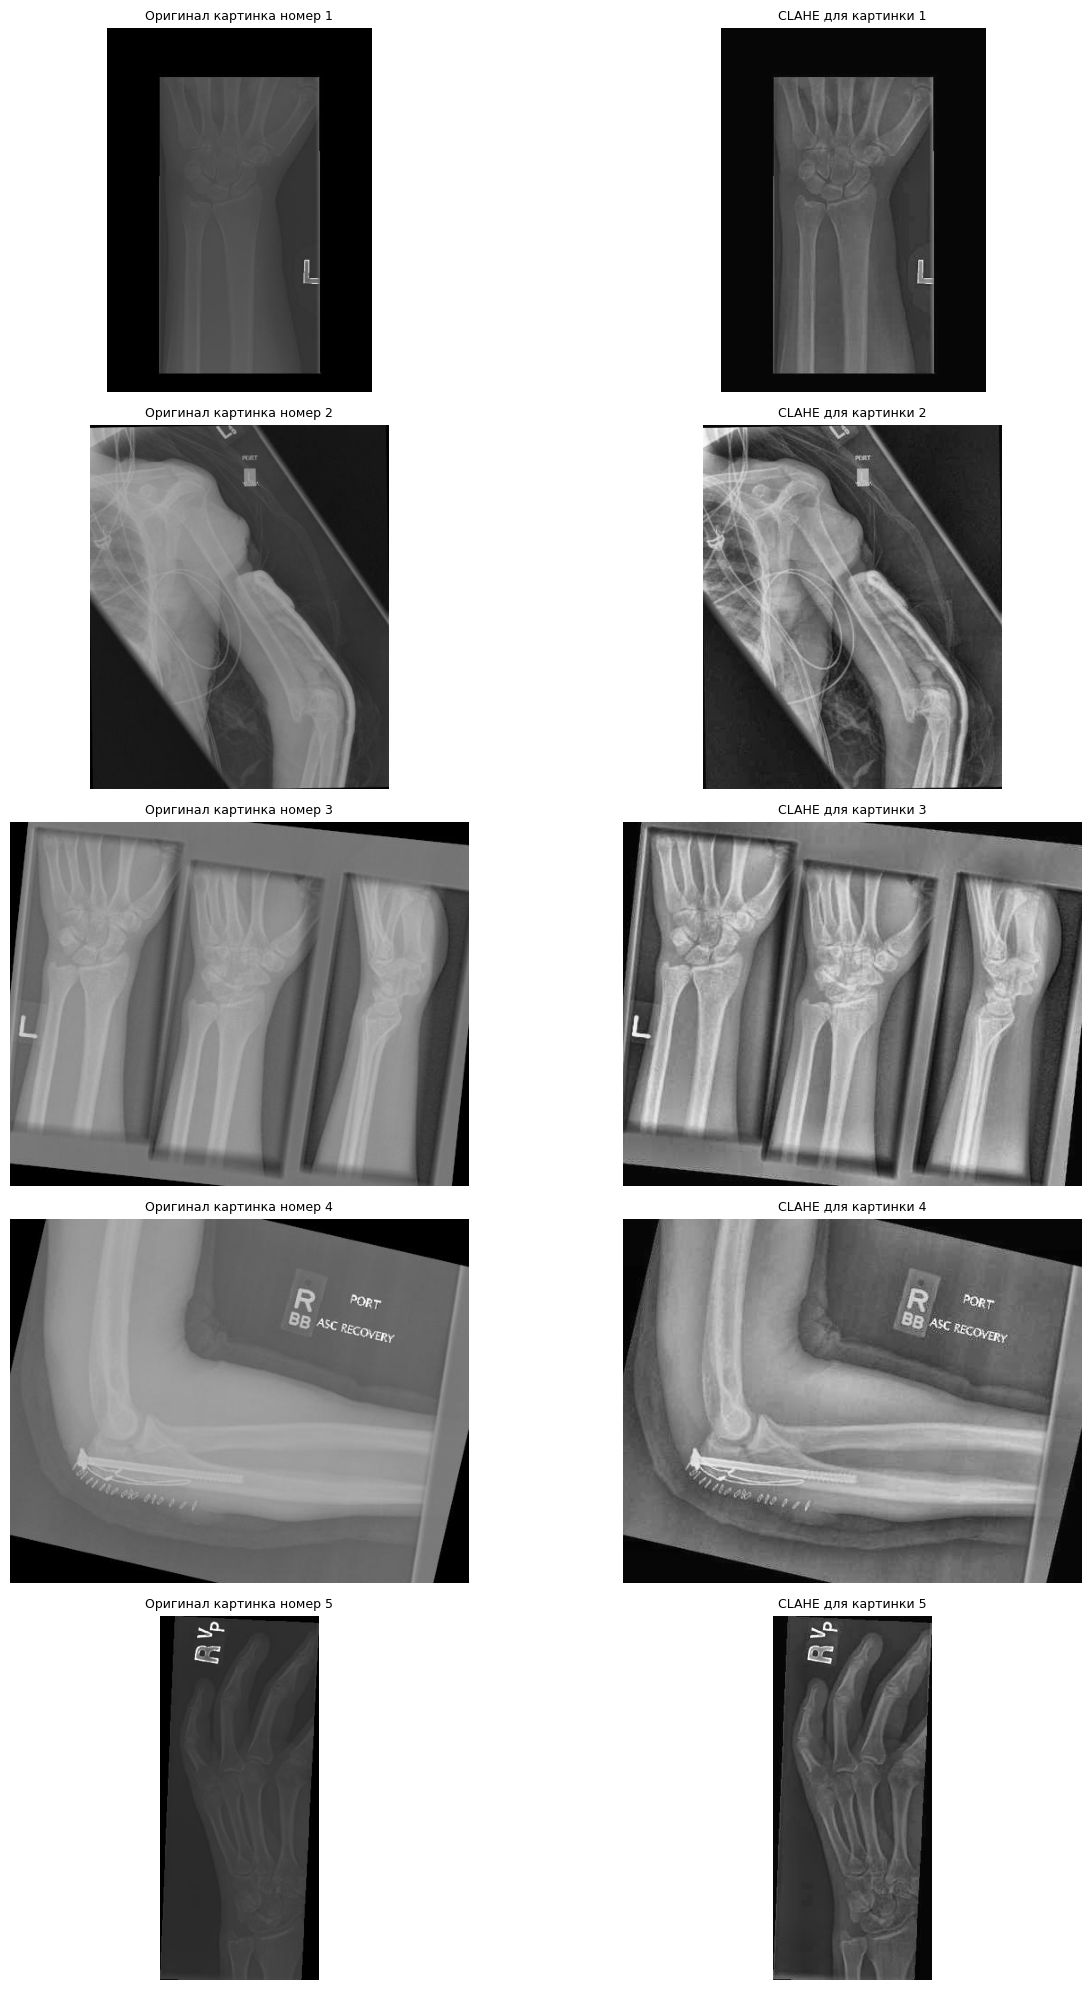

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

img_dir = '/content/BoneFractureYolo8/train/images'
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

# Получаем список изображений
for i, img in enumerate(os.listdir(img_dir)):
  if i == 5: break
  clahe = cv2.createCLAHE(clipLimit=3., tileGridSize=(8,8))
  image = cv2.imread(f'{img_dir}/{img}', 1)
  lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
  l, a, b = cv2.split(lab)
  l2 = clahe.apply(l)
  lab = cv2.merge((l2, a, b))
  img2 = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
  # Конвертируем BGR в RGB для matplotlib
  img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
  # Левая колонка - оригинал
  axes[i, 0].imshow(img_rgb)
  axes[i, 0].set_title(f"Оригинал картинка номер {i + 1}", fontsize=9)
  axes[i, 0].axis('off')
  # Правая колонка - CLAHE
  axes[i, 1].imshow(img2_rgb)
  axes[i, 1].set_title(f"CLAHE для картинки {i + 1}", fontsize=9)
  axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

Видно, что применение CLAHE по крайней мере визуально значительно повышает качество изображения для человеческого глаза, поэтому поробуем использовать этот метод при обучении

# Пробуем YOLO

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**yolov8m**

In [ ]:
# Скачали среднюю модель YOLOv8
model = YOLO("yolov8m.pt").to(device)

results = model.train(data="/content/BoneFractureYolo8/data.yaml", epochs=70, batch=16, device=0, name='baseline_yolov8m',
                      patience=20, imgsz=480) # тут маленький размер картинки, чтобы обучения происходило быстрее, это будет нашим baseline
# добавим раннюю остановку, если модель быстро сойдётся

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8m-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

Как видно, качество даже на тренировочных данных пока далеко от 0.6, поэтому продолжим наши эксперименты

Из статьи: https://medium.com/object-detection-tutorials/how-to-train-yolov8-bone-fracture-detection-on-x-rays-a3be5b3ec372, я узнал, что неплохое mAP даёт yolov8l - самая тяжеловесная модель, но попробовать я думаю стоит

In [ ]:
model = YOLO("yolov8l.pt").to(device)

results = model.train(data="/content/BoneFractureYolo8/data.yaml", epochs=70, batch=4, device=0, name='version_yolov8l',
                      patience=20, imgsz=800)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=version_yolov8l, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

Данная архитектура обучалась значительно дольше предыдущих, но при это как видно на 30 эпохе качество даже не стало 0.1 на mAP@50, что плохо и я решил закончить обучение, так как не думаю, что стоит ожидать улучшения метрик.

Отмечу, что я подробно разобрался с представленным форматом - OBB (oriented bounding box) и теперь мы попробуем не преобразовывать данные в YOLO формат, а будем использовать OBB

Здесь мы уже не меняем исходный формат с obb на YOLO, а просто исправляем ошибки в разметке для формата obb. Важно, этот код следует запускать вместо кода со сменой разметки на стандартную YOLO, иначе модели ниже не заработают как надо.

In [7]:
import os


dirs = ['/content/BoneFractureYolo8/test/labels', '/content/BoneFractureYolo8/train/labels',
        '/content/BoneFractureYolo8/valid/labels']

for dir in dirs:
  for file in os.listdir(dir):
    with open(f"{dir}/{file}", 'r') as cur_file:
      data = cur_file.readlines()
      to_write = []
      for elems in data:
        cur_elem = elems.split()
        if not cur_elem: continue # значит boundingbox'а на нашей картинке нет, а значит нет и перелома и файл просто пустой
        to_write.append(cur_elem[0:9]) # записываем не больше 9, так как один bounding box в obb формате должен иметь 9 значений - класс и 4 координаты
        # в нашем случае в датасете есть определённая проблема и первая координата повторяется в конце, поэтому мы её обрезаем
    with open(f"{dir}/{file}", 'w') as cur_file:
      for row in to_write:
        cur_file.write(' '.join((map(str, row))))
        cur_file.write('\n')
      cur_file.close()


In [ ]:
model = YOLO("yolo11m-obb.pt").to(device)

results = model.train(data="/content/BoneFractureYolo8/data.yaml", epochs=100, batch=4, device=0, name='version_yolov11m-obb',
                      patience=20, imgsz=800)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=version_yolov8l-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [ ]:
from ultralytics import YOLO


model = YOLO('best.pt')
results = model.val(
    data='/content/BoneFractureYolo8/data.yaml',
    split='test',
    imgsz=800,
    batch=1,
    conf=0.25,
    iou=0.5,
    device='cpu'
)


Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11m-obb summary (fused): 135 layers, 20,883,880 parameters, 0 gradients, 71.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 451.6±209.6 MB/s, size: 10.9 KB)
val: Scanning /content/BoneFractureYolo8/test/labels.cache... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 47.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 169/169 1.8s/it 5:03
                   all        169         96      0.511      0.269      0.229      0.103
        elbow positive         13         17          0          0          0          0
      fingers positive         22         27      0.667      0.222      0.188     0.0846
      forearm fracture         13         14       0.75      0.429       0.39       0.24
               humerus         14         15      0.625      0.333       0.29      0.124
     shoulder fracture      

Попробуем использовать SAHI

In [ ]:
# !pip install -U torch sahi ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.2 MB/s eta 0:00:00


Ниже код для SAHI, он не показался мне особо перспективным в нашей задаче, потому что он разрезает изображение на тайлы, но в нашем случае они довольно мелкие, плюс иногда в тайле может вообще не быть самой кости(может быть например только рамка снимка или что-то такое, поэтому я закомментировал код, но в целом оставил, потому что довольно подробно изучал этот подход).

In [ ]:
# !pip install -q ultralytics sahi pycocotools opencv-python-headless

In [ ]:
# import os
# import glob
# from sahi import AutoDetectionModel
# from sahi.predict import get_sliced_prediction
# from IPython.display import Image, display
# from sahi import AutoDetectionModel
# from sahi.utils.cv import read_image
# from sahi.utils.file import download_from_url
# from sahi.predict import get_prediction, get_sliced_prediction, predict
# from IPython.display import Image
# from sahi.slicing import slice_image


# output_dir = '/content/sahi_test_results'
# os.makedirs(output_dir, exist_ok=True)

# detection_model = AutoDetectionModel.from_pretrained(
#     model_type='yolo11',
#     model_path='/content/best (4).pt',
#     confidence_threshold=0.25,
#     device="cpu",
# )


# test_dir = '/content/BoneFractureYolo8/test/images'
# for file in os.listdir(test_dir):
#   name, ext = os.path.splitext(file)
#   file_path = f"{test_dir}/{file}"
#   cur_dir = f"{output_dir}/{name}"
#   # создаём директорию с текущим файлом и его тайлами
#   os.makedirs(cur_dir, exist_ok=True)
#   original_img = cv2.imread(file_path)
#   cv2.imwrite(f"{cur_dir}/original{ext}", original_img)
#   # получаем нарезанные изображения
#   slice_result = slice_image(
#       image=file_path,
#       slice_height=240,
#       slice_width=240,
#       overlap_height_ratio=0.2,
#       overlap_width_ratio=0.2,
#   )
#   for i, slice_img in enumerate(slice_result.images):
#     cv2.imwrite(f"{cur_dir}/slice{i + 1}.jpg", slice_img)

#   result = get_sliced_prediction(
#         file_path,
#         detection_model,
#         slice_height=240,
#         slice_width=240,
#         overlap_height_ratio=0.2,
#         overlap_width_ratio=0.2
#         )
#   result.export_visuals(export_dir=cur_dir, file_name='prediction')


# print(f"Done! Results saved to {output_dir}")
# print("\nShowing first 3 results:")




Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 9 slices.
Performing prediction on 6 slices.


KeyboardInterrupt: 

# Сделать получше

In [8]:
import cv2
import numpy as np
import os
import shutil
from tqdm import tqdm

def apply_clahe_lab(image, clip_limit=3.0, tile_grid_size=(8, 8)):
    """Применяем CLAHE"""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return img_clahe

def process_dataset_folder(input_img_dir, output_img_dir, clip_limit=3.0):
    """Обрабатывает одну папку с изображениями"""
    os.makedirs(output_img_dir, exist_ok=True)

    images = [f for f in os.listdir(input_img_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]


    for img_name in tqdm(images, desc="CLAHE"):
        img_path = os.path.join(input_img_dir, img_name)
        output_path = os.path.join(output_img_dir, img_name)

        # Читаем изображение
        img = cv2.imread(img_path)

        # применяем CLAHE
        img_clahe = apply_clahe_lab(img, clip_limit=clip_limit)

        # Сохраняем
        cv2.imwrite(output_path, img_clahe)

def copy_labels(input_lbl_dir, output_lbl_dir):
    """Копирует лейблы без изменений"""
    os.makedirs(output_lbl_dir, exist_ok=True)

    labels = [f for f in os.listdir(input_lbl_dir) if f.endswith('.txt')]

    for lbl_name in labels:
        src = os.path.join(input_lbl_dir, lbl_name)
        dst = os.path.join(output_lbl_dir, lbl_name)
        shutil.copy(src, dst)


base_input = '/content/BoneFractureYolo8'
base_output = '/content/BoneFractureYolo8CLAHE'

# Обрабатываем train/valid/test
for split in ['train', 'valid', 'test']:
    input_img = f'{base_input}/{split}/images'
    output_img = f'{base_output}/{split}/images'
    input_lbl = f'{base_input}/{split}/labels'
    output_lbl = f'{base_output}/{split}/labels'

    process_dataset_folder(input_img, output_img, clip_limit=3.0)
    copy_labels(input_lbl, output_lbl)

print("Обработка датасета завершена!")

CLAHE: 100%|██████████| 169/169 [00:01<00:00, 120.56it/s]


Обработка датасета завершена!


In [9]:
import os
import cv2
import glob
import yaml
import numpy as np

# Пути к выборкам
BASE_DIR = "BoneFractureYolo8CLAHE"
IMAGES_DIR = os.path.join(BASE_DIR, "test/images")
LABELS_DIR = os.path.join(BASE_DIR, "test/labels")
OUTPUT_DIR = os.path.join(BASE_DIR, "test/gt_obbs_visualized")

fracture_classes = ['elbow positive', 'fingers positive', 'forearm fracture',
                    'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']

os.makedirs(OUTPUT_DIR, exist_ok=True)

COLORS = [(204, 204, 0)]

def parse_obb_label(line, img_width, img_height):
    parts = line.strip().split()
    if len(parts) != 9:
        return None, None

    class_id = int(parts[0])

    # Собираем 4 точки (каждая пара x, y нормализована)
    corners = []
    for i in range(1, 9, 2):
        x_norm = float(parts[i])
        y_norm = float(parts[i + 1])
        x_px = int(x_norm * img_width)
        y_px = int(y_norm * img_height)
        corners.append([x_px, y_px])

    return class_id, np.array(corners, dtype=np.int32)

def draw_obb(image, corners, class_id, color):
    """
    Рисуем ориентированный bounding box (полигон из 4 точек) и подпись класса.
    """
    # Соединяем точки линиями (замыкаем полигон)
    for i in range(4):
        pt1 = tuple(corners[i])
        pt2 = tuple(corners[(i + 1) % 4])
        cv2.line(image, pt1, pt2, color, 2)

    # Подпись класса над первым углом
    label_text = fracture_classes[class_id]
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    thickness = 2

    # Вычисляем размер текста для фона
    (text_w, text_h), baseline = cv2.getTextSize(label_text, font, font_scale, thickness)

    # Позиция текста — над первым углом
    text_x = corners[0][0]
    text_y = corners[0][1] - 10

    # Фон под текст (чтобы читалось на любом фоне)
    cv2.rectangle(
        image,
        (text_x, text_y - text_h - 4),
        (text_x + text_w, text_y + baseline),
        color,
        -1  # залитый прямоугольник
    )
    cv2.putText(image, label_text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness)

# Получаем список изображений
image_files = glob.glob(os.path.join(IMAGES_DIR, "*.*"))
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_files = [f for f in image_files if os.path.splitext(f)[1].lower() in image_extensions]

print(f"Найдено изображений: {len(image_files)}")
processed = 0
skipped = 0

for img_path in image_files:
    img = cv2.imread(img_path)

    img_height, img_width, _ = img.shape
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(LABELS_DIR, base_name + ".txt")

    boxes_drawn = 0

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                class_id, corners = parse_obb_label(line, img_width, img_height)
                if class_id is None: continue
                color = COLORS[class_id % len(COLORS)]
                draw_obb(img, corners, class_id, color)
                boxes_drawn += 1

    # Сохраняем результат
    output_path = os.path.join(OUTPUT_DIR, os.path.basename(img_path))
    cv2.imwrite(output_path, img)
    processed += 1

    if processed % 50 == 0:
        print(f"  Обработано: {processed}/{len(image_files)}")

Найдено изображений: 169
  Обработано: 50/169
  Обработано: 100/169
  Обработано: 150/169


Протестируем качество наших лучших моделей

In [ ]:
from ultralytics import YOLO


model = YOLO('best (4).pt')
results = model.val(
    data='/content/BoneFractureYolo8/data.yaml',
    split='test',
    imgsz=640,
    batch=1,
    conf=0.25,
    iou=0.4,
    device='cpu'
) # поменять здесь на модель выше


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11m-obb summary (fused): 135 layers, 20,883,880 parameters, 0 gradients, 71.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 312.2±118.4 MB/s, size: 13.4 KB)
val: Scanning /content/BoneFractureYolo8/test/labels... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 1.1Kit/s 0.2s
val: New cache created: /content/BoneFractureYolo8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 169/169 1.5s/it 4:05
                   all        169         96      0.474      0.223      0.195     0.0981
        elbow positive         13         17       0.25     0.0588     0.0275     0.0165
      fingers positive         22         27      0.444      0.148       0.13     0.0782
      forearm fracture         13         14      0.714      0.357      0.321      0.158
               humerus         14         15        0.5

In [ ]:
from ultralytics import YOLO


model = YOLO('best (5).pt')
results = model.val(
    data='/content/BoneFractureYolo8/data.yaml',
    split='test',
    imgsz=640,
    batch=1,
    conf=0.25,
    iou=0.4,
    device='cpu'
) # поменять здесь на модель выше


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n-obb summary (fused): 110 layers, 2,655,088 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 370.0±176.4 MB/s, size: 10.6 KB)
val: Scanning /content/BoneFractureYolo8/test/labels.cache... 169 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 13.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 169/169 4.9it/s 34.7s
                   all        169         96      0.513      0.253      0.233      0.125
        elbow positive         13         17          0          0          0          0
      fingers positive         22         27      0.573      0.185      0.149     0.0552
      forearm fracture         13         14          1      0.357      0.355      0.259
               humerus         14         15      0.787      0.467      0.449      0.218
     shoulder fracture       

Как видно, последняя модель показала лучшее качество и время инференса, однако класс elbow positive лучше всего детектирует вторая модель

Наиболее важные эксперименты с графиками представлены в папках на гугл диске, там же находятся и модели. Ссылка: https://drive.google.com/drive/folders/1Nh4m7FtQeVezrChNcV0MrMC0HV_b4rp6?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto. Все эксперименты проводились на вычислительных мощностях Kaggle(так как они длились довольно долго от 2 часов). Отмечу, что по матрице путаниц (confusion matrix) видно, что модель не путает классы переломов, то есть не будет такого, что класс перелома elbow positive, а модель считает, что это forearm fracture. Главная проблема это дисбаланс классов и как следствие иногда модель может не найти перелом.